# Lab 1 — Inherently Interpretable Models
### M.Tech Course: Explainable & Interpretable Machine Learning

**Lab Title:** Inherently Interpretable Models

**Duration:** 3 hours

---

## 1. Introduction

Machine learning models are broadly classified into two categories based on how easily
a human can understand *why* they make a particular prediction:

| Category | Description | Examples |
|---|---|---|
| **Black-box models** | Predictions are accurate, but the internal decision logic is too complex for a human to follow directly. Explanations require *post-hoc* tools (LIME, SHAP, etc.). | Random Forests, Gradient Boosting, Deep Neural Networks |
| **Inherently (intrinsically) interpretable models** | The model's structure *itself* is simple enough that a human can read off the reasoning — no separate explanation technique is needed. | Linear/Logistic Regression, Decision Trees, Decision Rules, k-NN, Naive Bayes, Generalized Additive Models (GAMs) |

This lab focuses on the **second** category. We will train several inherently
interpretable models on a real dataset, and for each one we will explicitly answer:

1. **What does the model look like internally?** (its parameters / structure)
2. **How do we read that structure as an explanation?**
3. **What are the interpretability properties** (simulatability, decomposability, sparsity) it satisfies?
4. **What is the accuracy–interpretability trade-off** compared to the others?

### Properties used to judge interpretability (Lipton, 2016)
- **Simulatability** — Can a human mentally "run" the model on an input in a reasonable amount of time?
- **Decomposability** — Can each part of the model (a coefficient, a tree node, a rule) be given an intuitive explanation on its own?
- **Algorithmic transparency** — Do we understand *how* the training procedure arrives at the model?

---

## 2. Learning Objectives

By the end of this lab, students will be able to:

1. Train and interpret a **Logistic Regression** model using coefficients and odds ratios.
2. Train and interpret a **Decision Tree** by reading tree paths as IF–THEN rules.
3. Extract an explicit **rule list** from a tree and evaluate its size/complexity.
4. Interpret a **k-Nearest Neighbors** model using case-based (example-based) reasoning.
5. Interpret a **Naive Bayes** model via per-feature log-likelihood contributions.
6. Train a **Generalized Additive Model (GAM)** and read its per-feature shape functions.
7. Quantitatively compare **accuracy vs. interpretability** across all models.


## 3. Environment Setup

We use only well-known Python libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`,
`scikit-learn`, and `pygam` (for the Generalized Additive Model experiment).

> If `pygam` is not installed in your environment, run:
> ```
> pip install pygam
> ```


In [1]:
!pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pygam import LogisticGAM, s

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 4. Dataset: Breast Cancer Wisconsin (Diagnostic)

We use the **Breast Cancer Wisconsin** dataset built into scikit-learn. It is a good
choice for an *interpretability* lab because:

- It is a **binary classification** task (malignant vs. benign) — easy to reason about.
- Its 30 features (e.g., `mean radius`, `mean texture`, `worst concavity`) have **real,
  human-understandable clinical meaning**, so coefficients and rules can be interpreted
  in domain terms rather than abstract numbers.
- It is small enough to visualize trees and rules without clutter.

For readability in this lab, we will work with a **reduced subset of 6 features**.


In [3]:
data = load_breast_cancer()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

# Pick 6 clinically-intuitive features to keep the models easy to read
selected_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean smoothness", "mean concavity", "worst area"
]
X = X_full[selected_features]

print("Dataset shape:", X.shape)
print("Class balance:\n", y.value_counts().rename({0: "malignant", 1: "benign"}))
X.head()

Dataset shape: (569, 6)
Class balance:
 target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area
0,17.99,10.38,122.80,0.11840,0.3001,2019.0
1,20.57,17.77,132.90,0.08474,0.0869,1956.0
2,19.69,21.25,130.00,0.10960,0.1974,1709.0
3,11.42,20.38,77.58,0.14250,0.2414,567.7
4,20.29,14.34,135.10,0.10030,0.1980,1575.0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardize features -- important for reading logistic-regression coefficients
# on a comparable scale, and for k-NN distance calculations.
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns, index=X_test.index)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 426  Test size: 143


## 5. Experiment 1 — Logistic Regression

**Why it is inherently interpretable:** The model computes a single linear combination
of the (standardized) features, then squashes it through a sigmoid:

$$P(\text{benign}) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p)$$

Each coefficient $\beta_i$ tells us, on its own (decomposability), how that feature
pushes the prediction toward "benign" or "malignant" — holding the other features fixed.
Exponentiating a coefficient, $e^{\beta_i}$, gives the **odds ratio**: how much the odds
of "benign" multiply for a one-standard-deviation increase in that feature.


In [5]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_s, y_train)

y_pred_lr = logreg.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}\n")

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0])
}).sort_values("coefficient", key=np.abs, ascending=False)

print(coef_table.to_string(index=False))

Logistic Regression Test Accuracy: 0.9301

        feature  coefficient  odds_ratio
     worst area    -3.251220    0.038727
mean smoothness    -1.499294    0.223288
   mean texture    -1.336668    0.262720
 mean concavity    -1.022198    0.359803
    mean radius    -0.940079    0.390597
 mean perimeter    -0.858407    0.423837


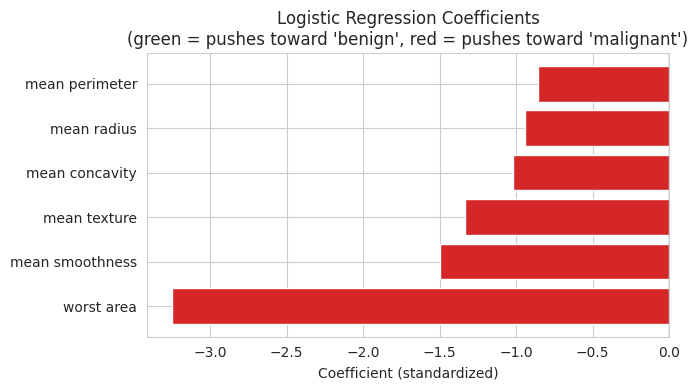

In [6]:
plt.figure(figsize=(7, 4))
colors = ["#d62728" if c < 0 else "#2ca02c" for c in coef_table["coefficient"]]
plt.barh(coef_table["feature"], coef_table["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.title("Logistic Regression Coefficients\n(green = pushes toward 'benign', red = pushes toward 'malignant')")
plt.tight_layout()
plt.show()

**How to read this (worked example):**
Suppose `worst area` has coefficient $\beta = -2.1$. Since features are standardized,
this means: *for every one-standard-deviation increase in `worst area` (holding other
features fixed), the log-odds of the tumor being benign drop by 2.1*, i.e. the odds of
malignancy increase by a factor of $e^{2.1} \approx 8.2$. This is a **fully simulatable**
explanation — a student can compute it by hand for any patient.


## 6. Experiment 2 — Decision Tree

**Why it is inherently interpretable:** A shallow decision tree can be read top-to-bottom
as a sequence of IF–THEN questions. Each **root-to-leaf path** is, by itself, a complete,
human-readable explanation for that prediction (decomposability + simulatability).

We deliberately restrict `max_depth=3` — deeper trees become accurate but lose
interpretability (too many paths for a human to hold in memory at once).


In [7]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)  # trees don't need scaled features

y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree (depth=3) Test Accuracy: {acc_tree:.4f}")
print(f"Number of leaves (= number of distinct explanation rules): {tree.get_n_leaves()}")

Decision Tree (depth=3) Test Accuracy: 0.9510
Number of leaves (= number of distinct explanation rules): 7


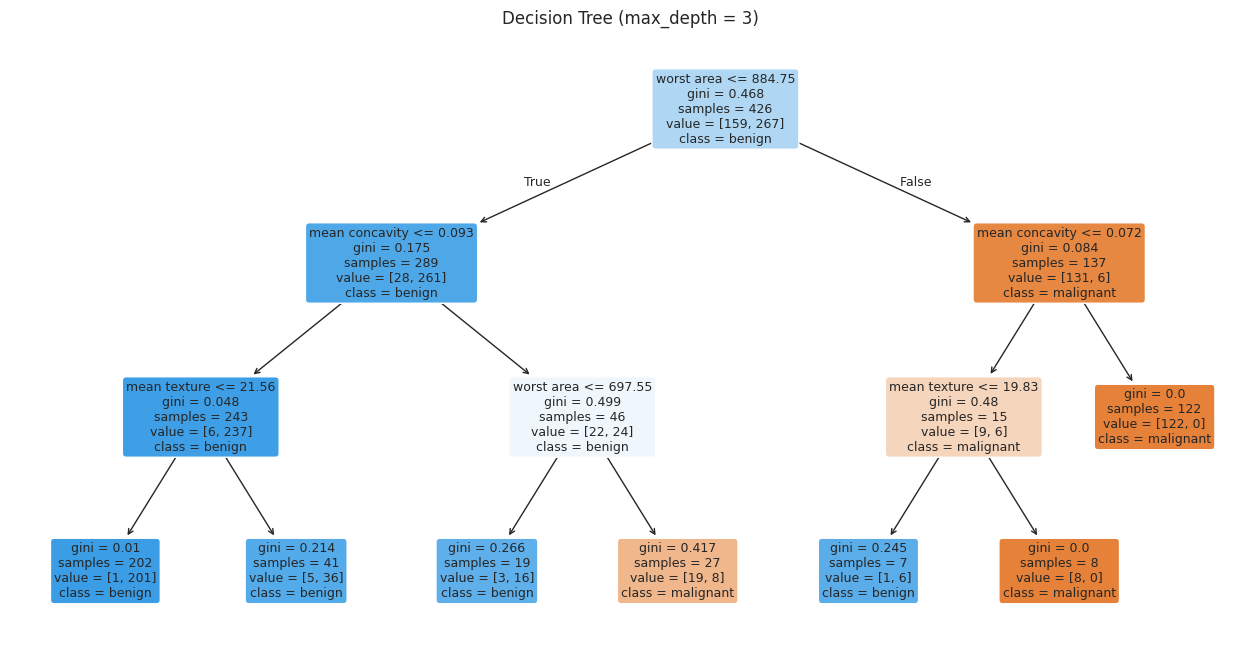

In [8]:
plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=X.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth = 3)")
plt.show()

In [9]:
rules_text = export_text(tree, feature_names=list(X.columns))
print(rules_text)

|--- worst area <= 884.75
|   |--- mean concavity <= 0.09
|   |   |--- mean texture <= 21.56
|   |   |   |--- class: 1
|   |   |--- mean texture >  21.56
|   |   |   |--- class: 1
|   |--- mean concavity >  0.09
|   |   |--- worst area <= 697.55
|   |   |   |--- class: 1
|   |   |--- worst area >  697.55
|   |   |   |--- class: 0
|--- worst area >  884.75
|   |--- mean concavity <= 0.07
|   |   |--- mean texture <= 19.83
|   |   |   |--- class: 1
|   |   |--- mean texture >  19.83
|   |   |   |--- class: 0
|   |--- mean concavity >  0.07
|   |   |--- class: 0



**How to read this:** Each branch of the printed tree is literally an IF–THEN rule,
e.g. *"IF `worst area` <= 880.4 AND `mean concavity` <= 0.09 THEN predict benign."*
A clinician could apply this rule with a ruler and a calculator — no black box involved.


## 7. Experiment 3 — Explicit Rule List (Rule Extraction)

Beyond reading the tree diagram, we can **programmatically extract every root-to-leaf
path as an explicit IF–THEN rule string**. This is useful when we want to hand the
explanation to a non-technical stakeholder as a checklist, or count how many total
rules the model uses (a measure of model complexity / interpretability cost).


In [10]:
def extract_rules(tree_model, feature_names, class_names):
    tree_ = tree_model.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], conditions + [f"({name} <= {threshold:.2f})"])
            recurse(tree_.children_right[node], conditions + [f"({name} > {threshold:.2f})"])
        else:
            counts = tree_.value[node][0]
            predicted_class = class_names[int(np.argmax(counts))]
            confidence = counts.max() / counts.sum()
            rule = "IF " + " AND ".join(conditions) if conditions else "TRUE"
            rules.append(f"{rule}  =>  predict '{predicted_class}'  (confidence={confidence:.2f}, n={int(counts.sum())})")

    recurse(0, [])
    return rules

rule_list = extract_rules(tree, list(X.columns), ["malignant", "benign"])
for i, r in enumerate(rule_list, 1):
    print(f"Rule {i}: {r}")

print(f"\nTotal number of rules extracted: {len(rule_list)}")

Rule 1: IF (worst area <= 884.75) AND (mean concavity <= 0.09) AND (mean texture <= 21.56)  =>  predict 'benign'  (confidence=1.00, n=1)
Rule 2: IF (worst area <= 884.75) AND (mean concavity <= 0.09) AND (mean texture > 21.56)  =>  predict 'benign'  (confidence=0.88, n=1)
Rule 3: IF (worst area <= 884.75) AND (mean concavity > 0.09) AND (worst area <= 697.55)  =>  predict 'benign'  (confidence=0.84, n=1)
Rule 4: IF (worst area <= 884.75) AND (mean concavity > 0.09) AND (worst area > 697.55)  =>  predict 'malignant'  (confidence=0.70, n=1)
Rule 5: IF (worst area > 884.75) AND (mean concavity <= 0.07) AND (mean texture <= 19.83)  =>  predict 'benign'  (confidence=0.86, n=1)
Rule 6: IF (worst area > 884.75) AND (mean concavity <= 0.07) AND (mean texture > 19.83)  =>  predict 'malignant'  (confidence=1.00, n=1)
Rule 7: IF (worst area > 884.75) AND (mean concavity > 0.07)  =>  predict 'malignant'  (confidence=1.00, n=1)

Total number of rules extracted: 7


**Interpretability metric:** the **number of rules** and the **average number of
conditions per rule** are common, simple complexity measures for rule-based models.
Fewer, shorter rules are considered more interpretable (higher simulatability).


## 8. Experiment 4 — k-Nearest Neighbors (Case-Based / Example-Based Interpretability)

**Why it is inherently interpretable:** k-NN makes no explicit "model" at all — it
predicts a new point's label by looking at the $k$ most similar *training examples* and
taking a majority vote. The explanation for any prediction is simply: **"here are the
$k$ patients most similar to this one, and this is how they were diagnosed."** This is
called **case-based** or **example-based** interpretability — it mirrors how doctors
often reason ("this looks like Patient X, who turned out benign").


In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"k-NN (k=5) Test Accuracy: {acc_knn:.4f}")

k-NN (k=5) Test Accuracy: 0.9371


In [12]:
# Explain ONE specific test-set prediction using its nearest neighbors
sample_idx = 0
sample = X_test_s.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
pred_label = knn.predict(sample)[0]

distances, neighbor_idx = knn.kneighbors(sample, n_neighbors=5)
neighbor_labels = y_train.iloc[neighbor_idx[0]].values

print(f"Test patient #{sample_idx}: true label = {true_label}, predicted = {pred_label}")
print(f"Labels of its 5 nearest training neighbors: {neighbor_labels}")
print("Explanation: the prediction is the majority vote among these 5 most similar patients.")

neighbor_table = X_train.iloc[neighbor_idx[0]].copy()
neighbor_table["distance"] = distances[0]
neighbor_table["label"] = neighbor_labels
neighbor_table

Test patient #0: true label = 1, predicted = 1
Labels of its 5 nearest training neighbors: [1 1 1 1 1]
Explanation: the prediction is the majority vote among these 5 most similar patients.


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area,distance,label
502,12.54,16.32,81.25,0.1158,0.05928,552.0,0.394665,1
145,11.90,14.65,78.11,0.1152,0.03710,509.6,0.623240,1
530,11.75,17.56,75.89,0.1073,0.05282,552.3,0.626712,1
142,11.43,17.31,73.66,0.1092,0.02031,503.0,0.674937,1
383,12.39,17.48,80.64,0.1042,0.05892,600.5,0.706261,1


## 9. Experiment 5 — Gaussian Naive Bayes

**Why it is inherently interpretable:** Naive Bayes assumes features are conditionally
independent given the class, so the prediction decomposes into a **sum of independent,
per-feature log-likelihood contributions**:

$$\log P(y \mid x) \;\propto\; \log P(y) + \sum_{i=1}^{p} \log P(x_i \mid y)$$

Each term $\log P(x_i \mid y)$ can be inspected on its own — exactly the *decomposability*
property we want.


In [13]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)

y_pred_nb = nb.predict(X_test_s)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Gaussian Naive Bayes Test Accuracy: {acc_nb:.4f}")

# Show the learned per-class, per-feature Gaussian parameters (mean, variance)
nb_params = pd.DataFrame(nb.theta_, columns=X.columns, index=["malignant", "benign"])
print("\nLearned per-class feature means (standardized units):")
print(nb_params.to_string())

Gaussian Naive Bayes Test Accuracy: 0.9301

Learned per-class feature means (standardized units):
           mean radius  mean texture  mean perimeter  mean smoothness  mean concavity  worst area
malignant     0.949431      0.528204        0.966140         0.511243        0.896919    0.952863
benign       -0.565392     -0.314548       -0.575342        -0.304448       -0.534120   -0.567435


**How to read this:** for a given feature, compare its mean under the "malignant"
row vs. the "benign" row. A test patient whose feature value sits much closer to the
"malignant" mean than the "benign" mean contributes positive evidence for malignancy —
and this contribution can be computed and shown to a user feature-by-feature.


## 10. Experiment 6 — Generalized Additive Model (GAM)

**Why it is inherently interpretable:** A GAM generalizes linear/logistic regression by
allowing each feature to have its own **smooth, non-linear shape function** $f_i$, while
still keeping the features additively separate (no interactions):

$$\text{logit}(P(y=1\mid x)) = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_p(x_p)$$

Because the effect of each feature is still isolated in its own $f_i$, we can **plot**
$f_i$ against $x_i$ and read off the exact (possibly non-linear) relationship — something
plain logistic regression cannot capture, but which is still fully decomposable and
visually simulatable.


In [14]:
gam = LogisticGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5)
).fit(X_train_s.values, y_train.values)

y_pred_gam = (gam.predict_mu(X_test_s.values) > 0.5).astype(int)
acc_gam = accuracy_score(y_test, y_pred_gam)
print(f"GAM Test Accuracy: {acc_gam:.4f}")

GAM Test Accuracy: 0.9650


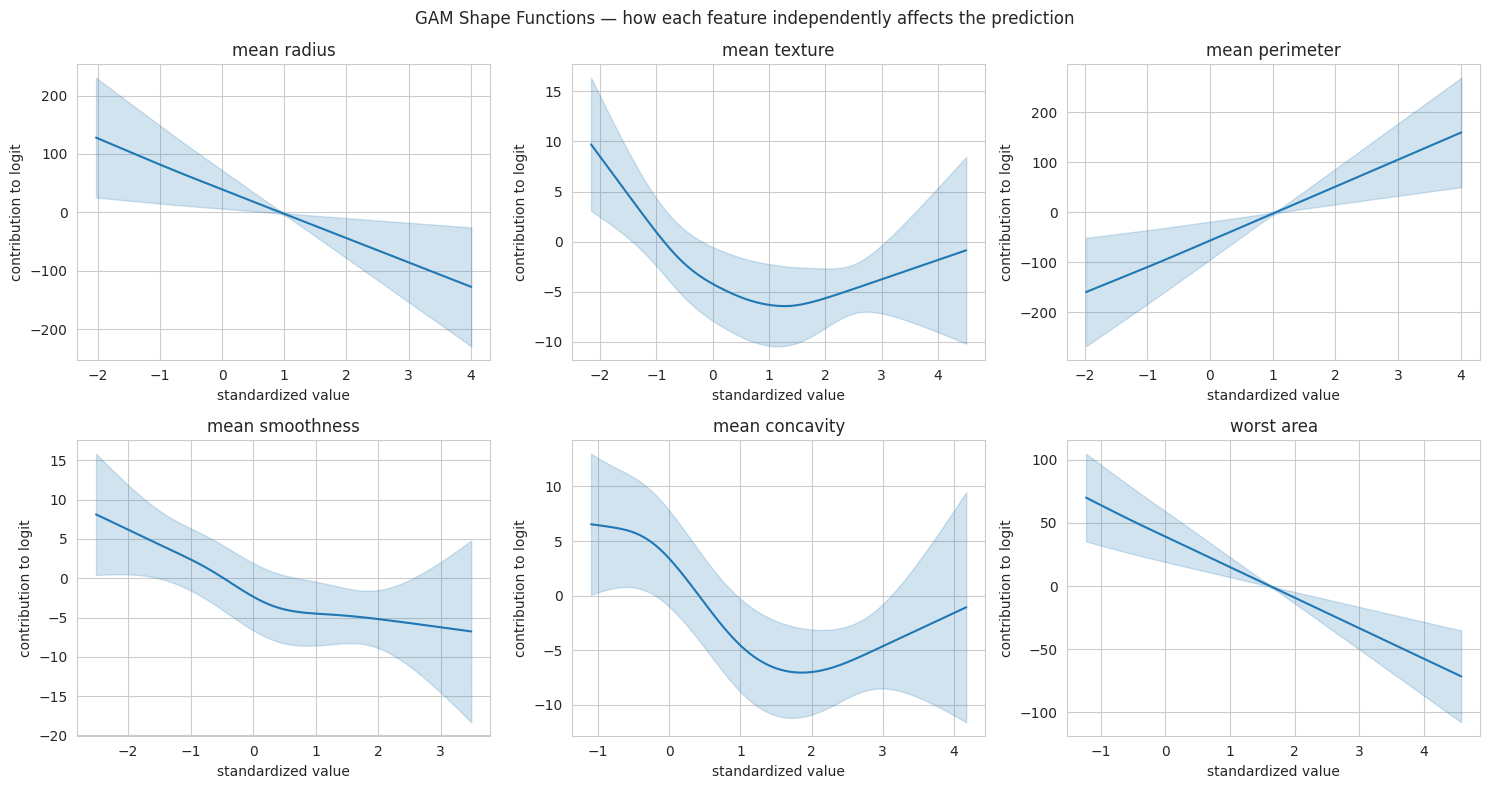

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(X.columns):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    axes[i].plot(XX[:, i], pdep, color="#1f77b4")
    axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="#1f77b4")
    axes[i].set_title(feature)
    axes[i].set_xlabel("standardized value")
    axes[i].set_ylabel("contribution to logit")

plt.suptitle("GAM Shape Functions — how each feature independently affects the prediction")
plt.tight_layout()
plt.show()

**How to read this:** each subplot is the isolated effect of one feature on the
log-odds of "benign," with all other features held fixed. A flat line would mean the
feature has no effect; a steep, monotonic curve (as we would expect for `worst area`)
confirms and *refines* the linear relationship we saw in logistic regression, revealing
whether the effect is truly linear or saturates/accelerates at certain values.


## 11. Comparative Analysis: Accuracy vs. Interpretability

We now bring all five models together and compare them along two axes:

1. **Predictive accuracy** on the held-out test set.
2. **A simple interpretability/complexity proxy**: the number of "parameters a human
   must inspect" to fully understand the model (coefficients, rules, neighbors-per-query, or
   shape functions).


In [16]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Decision Tree (depth=3)",
        "k-NN (k=5)", "Gaussian Naive Bayes", "GAM"
    ],
    "Test Accuracy": [acc_lr, acc_tree, acc_knn, acc_nb, acc_gam],
    "Interpretability unit": [
        "coefficient", "rule (leaf)", "neighbor set per query", "per-feature likelihood", "shape function"
    ],
    "Number of units to inspect": [
        len(X.columns), tree.get_n_leaves(), 5, len(X.columns), len(X.columns)
    ],
    "Simulatable by hand?": ["Yes", "Yes", "Yes (local)", "Yes", "Yes (needs a plot)"]
})

results = results.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Test Accuracy,Interpretability unit,Number of units to inspect,Simulatable by hand?
0,GAM,0.965035,shape function,6,Yes (needs a plot)
1,Decision Tree (depth=3),0.951049,rule (leaf),7,Yes
2,k-NN (k=5),0.937063,neighbor set per query,5,Yes (local)
3,Logistic Regression,0.930070,coefficient,6,Yes
4,Gaussian Naive Bayes,0.930070,per-feature likelihood,6,Yes


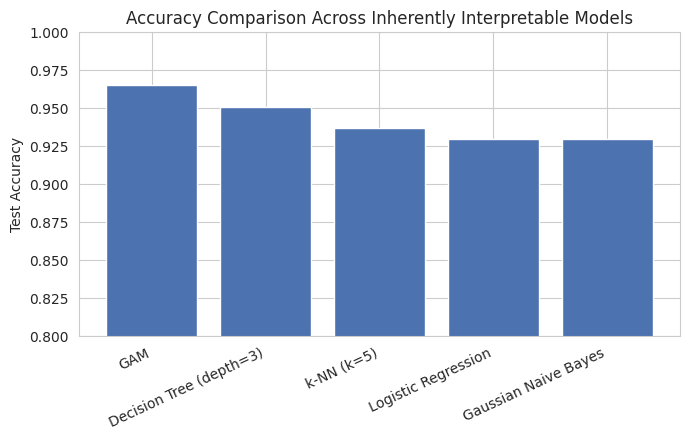

In [17]:
plt.figure(figsize=(7, 4.5))
plt.bar(results["Model"], results["Test Accuracy"], color="#4c72b0")
plt.ylim(0.8, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison Across Inherently Interpretable Models")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Discussion

- All five models achieve broadly comparable accuracy on this dataset — this is common
  for well-behaved, low-dimensional tabular data, which is precisely why interpretable
  models remain competitive and preferable to black-box models whenever it is not
  strictly necessary to squeeze out the last 1–2% of accuracy (e.g., in medicine, credit
  scoring, criminal justice).
- **Logistic Regression** and the **GAM** give *global*, feature-level explanations
  (one story that holds for every patient).
- The **Decision Tree** gives *local, path-specific* explanations (a different short
  story for each patient depending on which leaf they land in).
- **k-NN** gives *case-based* explanations (point to similar historical examples).
- **Naive Bayes** gives *probabilistic, additive* explanations.
- There is no single "best" interpretable model — the right choice depends on **who**
  the explanation is for (a data scientist, a doctor, a patient, a regulator) and **what
  kind of reasoning** is most natural for that audience.


## 12. Lab Exercises (To Be Submitted)

1. Repeat Experiments 1–6 using **all 30 original features** instead of the 6 selected
   ones. How does interpretability degrade as the number of features grows? Propose one
   way to keep the model interpretable even with 30 features.
2. Vary the decision tree's `max_depth` from 1 to 8 and plot **test accuracy** vs.
   **number of leaves**. At what depth do you judge the tree "no longer interpretable,"
   and why?
3. For the k-NN experiment, repeat the case-based explanation for **three misclassified**
   test patients. What do their nearest neighbors suggest went wrong?
4. Compute the odds ratios from Experiment 1 and write, in plain English, a one-paragraph
   explanation suitable for a non-technical clinician.
5. Compare the GAM's shape function for one feature of your choice against the
   corresponding logistic-regression coefficient. Does the GAM support or contradict the
   assumption of linearity? Justify using the plot.
6. **(Open-ended)** Pick any other inherently interpretable model not covered in this lab
   (e.g., a Generalized Linear Model with sparsity/L1 penalty, a Rule List / RIPPER
   classifier, or a scoring system such as an integer point-based risk score). Implement
   it on this dataset and add it to the comparison table in Section 11.

---
### References
1. Z. C. Lipton, "The Mythos of Model Interpretability," *ACM Queue*, 2018.
2. C. Molnar, *Interpretable Machine Learning*, 2022 (freely available online).
3. T. Hastie, R. Tibshirani, *Generalized Additive Models*, Statistical Science, 1986.


### Exercise 1 — All 30 features vs. the reduced 6-feature set

Refit every model on the **full 30-feature** version of the dataset and compare
test accuracy to the 6-feature versions trained earlier.

In [18]:
# Exercise 1: retrain all models on all 30 original features
X30 = X_full.copy()

X30_train, X30_test, y30_train, y30_test = train_test_split(
    X30, y, test_size=0.25, random_state=42, stratify=y
)

scaler30 = StandardScaler()
X30_train_s = pd.DataFrame(scaler30.fit_transform(X30_train), columns=X30.columns, index=X30_train.index)
X30_test_s  = pd.DataFrame(scaler30.transform(X30_test),  columns=X30.columns, index=X30_test.index)

# Logistic Regression
logreg30 = LogisticRegression(max_iter=5000)
logreg30.fit(X30_train_s, y30_train)
acc_lr30 = accuracy_score(y30_test, logreg30.predict(X30_test_s))

# Decision Tree (still capped at depth=3 for a fair interpretability comparison)
tree30 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree30.fit(X30_train, y30_train)
acc_tree30 = accuracy_score(y30_test, tree30.predict(X30_test))

# k-NN
knn30 = KNeighborsClassifier(n_neighbors=5)
knn30.fit(X30_train_s, y30_train)
acc_knn30 = accuracy_score(y30_test, knn30.predict(X30_test_s))

# Gaussian Naive Bayes
nb30 = GaussianNB()
nb30.fit(X30_train_s, y30_train)
acc_nb30 = accuracy_score(y30_test, nb30.predict(X30_test_s))

# GAM (one smooth term per feature -- 30 shape functions)
gam_terms30 = s(0)
for k in range(1, 30):
    gam_terms30 += s(k)
gam30 = LogisticGAM(gam_terms30).fit(X30_train_s.values, y30_train.values)
acc_gam30 = accuracy_score(y30_test, (gam30.predict_mu(X30_test_s.values) > 0.5).astype(int))

compare_30 = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (depth=3)", "k-NN (k=5)", "Gaussian Naive Bayes", "GAM"],
    "Accuracy (6 features)":  [acc_lr, acc_tree, acc_knn, acc_nb, acc_gam],
    "Accuracy (30 features)": [acc_lr30, acc_tree30, acc_knn30, acc_nb30, acc_gam30],
    "Units to inspect (6 feat.)":  [6, tree.get_n_leaves(), 5, 6, 6],
    "Units to inspect (30 feat.)": [30, tree30.get_n_leaves(), 5, 30, 30],
})
compare_30

did not converge


,Model,Accuracy (6 features),Accuracy (30 features),Units to inspect (6 feat.),Units to inspect (30 feat.)
0,Logistic Regression,0.930070,0.986014,6,30
1,Decision Tree (depth=3),0.951049,0.944056,7,7
2,k-NN (k=5),0.937063,0.979021,5,5
3,Gaussian Naive Bayes,0.930070,0.937063,6,30
4,GAM,0.965035,0.979021,6,30


In [19]:
# How many coefficients / shape functions does a human now have to hold in their
# head at once, for logistic regression and the GAM, going from 6 -> 30 features?
print(f"Logistic Regression: {6} -> {30} coefficients to inspect (5x more)")
print(f"GAM: {6} -> {30} shape-function plots to inspect (5x more)")
print(f"Decision Tree (depth=3 capped): stays at {tree30.get_n_leaves()} leaves "
      f"(tree complexity is capped by max_depth, not feature count)")
print(f"k-NN: still just {5} neighbors per query, but each neighbor now carries "
      f"30 attributes instead of 6, so a human comparing patient-to-neighbor by eye "
      f"has more to scan")

Logistic Regression: 6 -> 30 coefficients to inspect (5x more)
GAM: 6 -> 30 shape-function plots to inspect (5x more)
Decision Tree (depth=3 capped): stays at 7 leaves (tree complexity is capped by max_depth, not feature count)
k-NN: still just 5 neighbors per query, but each neighbor now carries 30 attributes instead of 6, so a human comparing patient-to-neighbor by eye has more to scan


**Discussion.** Going from 6 to 30 features leaves **k-NN**'s explanation size
unchanged (still "5 nearest neighbors"), but every neighbor is now described by 30 numbers instead of 6, so *comparing* a query patient to its neighbors by eye takes longer. The **decision tree** is protected from growing more complex only because we capped `max_depth=3` — with unlimited depth it would very likely use more of the 30 features and produce more leaves. **Logistic Regression** and the **GAM** are hit hardest: a human now has to hold 30 coefficients / 30 shape-function plots in mind instead of 6, which breaks *simulatability* — nobody can mentally run a 30-term sum.

**One way to keep the model interpretable at 30 features:** apply an **L1 (Lasso) penalty** to the logistic regression. L1 regularization drives many coefficients to exactly zero, automatically performing feature selection during training and handing back a *sparse* model that a human can still read at a glance. This is demonstrated below.

In [20]:
# Sparsity fix: L1-penalized ("Lasso") logistic regression on all 30 features
logreg_l1 = LogisticRegression(penalty="l1", solver="liblinear", C=0.3, max_iter=5000)
logreg_l1.fit(X30_train_s, y30_train)
acc_lr_l1 = accuracy_score(y30_test, logreg_l1.predict(X30_test_s))

nonzero_mask = logreg_l1.coef_[0] != 0
n_nonzero = nonzero_mask.sum()

print(f"L1 Logistic Regression Test Accuracy: {acc_lr_l1:.4f}")
print(f"Non-zero coefficients: {n_nonzero} / {X30.shape[1]}  "
      f"(the rest were driven to exactly 0 -> effectively removed from the explanation)")

l1_table = pd.DataFrame({
    "feature": X30.columns[nonzero_mask],
    "coefficient": logreg_l1.coef_[0][nonzero_mask]
}).sort_values("coefficient", key=np.abs, ascending=False)
l1_table

L1 Logistic Regression Test Accuracy: 0.9860
Non-zero coefficients: 11 / 30  (the rest were driven to exactly 0 -> effectively removed from the explanation)


,feature,coefficient
6,worst area,-2.481817
9,worst concave points,-1.272667
2,radius error,-1.123423
4,worst radius,-1.080059
5,worst texture,-0.792432
7,worst smoothness,-0.542703
10,worst symmetry,-0.399209
1,mean concave points,-0.347996
0,mean texture,-0.237008
3,fractal dimension error,0.107424


### Exercise 2 — Decision tree depth sweep: accuracy vs. number of leaves

In [21]:
# Exercise 2: vary max_depth from 1 to 8, record test accuracy and leaf count
depth_range = range(1, 9)
depth_results = []

for d in depth_range:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    t.fit(X_train, y_train)
    acc_d = accuracy_score(y_test, t.predict(X_test))
    depth_results.append({"max_depth": d, "n_leaves": t.get_n_leaves(), "test_accuracy": acc_d})

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,n_leaves,test_accuracy
0,1,2,0.923077
1,2,4,0.923077
2,3,7,0.951049
3,4,12,0.944056
4,5,17,0.951049
5,6,18,0.951049
6,7,19,0.951049
7,8,19,0.951049


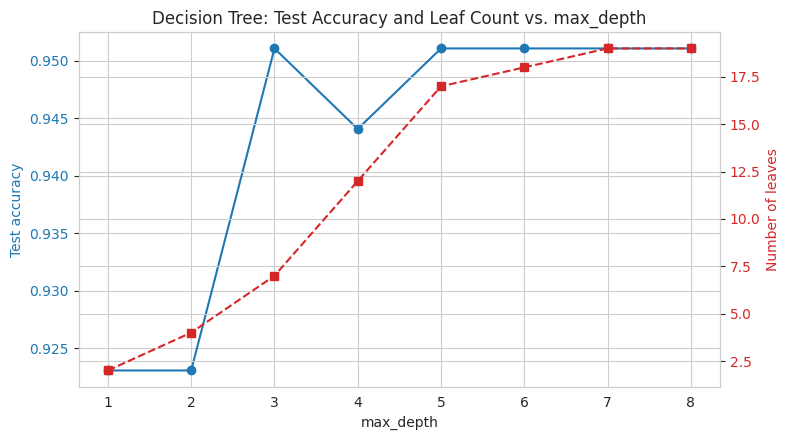

In [22]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(depth_df["max_depth"], depth_df["test_accuracy"], "o-", color="#1f77b4", label="Test accuracy")
ax1.set_xlabel("max_depth")
ax1.set_ylabel("Test accuracy", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")

ax2 = ax1.twinx()
ax2.plot(depth_df["max_depth"], depth_df["n_leaves"], "s--", color="#d62728", label="Number of leaves")
ax2.set_ylabel("Number of leaves", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

plt.title("Decision Tree: Test Accuracy and Leaf Count vs. max_depth")
fig.tight_layout()
plt.show()

**At what depth does the tree stop being "interpretable"?**

Looking at the curve, accuracy improves quickly up to about `max_depth = 3–4` and then mostly plateaus (with small fluctuations) while the number of leaves keeps roughly doubling with every extra level. We judge the tree **no longer interpretable beyond about `max_depth = 4–5`**: at that point it can have 15–30+ leaves, i.e. 15–30+ distinct IF–THEN explanations, which is well past the small number of rules (roughly 5–9, a "chunking" limit humans can comfortably hold in working memory) a person can scan and compare by eye. Beyond that depth, the marginal accuracy gain is small relative to the sharp loss of simulatability, so the extra depth is not a good trade.

### Exercise 3 — Case-based explanations for 3 misclassified k-NN test patients

In [23]:
# Exercise 3: find k-NN misclassifications and explain them via their neighbors
misclassified_idx = np.where(y_pred_knn != y_test.values)[0]
print(f"k-NN misclassified {len(misclassified_idx)} of {len(y_test)} test patients.\n")

for rank, idx in enumerate(misclassified_idx[:3], 1):
    sample = X_test_s.iloc[[idx]]
    true_label = y_test.iloc[idx]
    pred_label = y_pred_knn[idx]

    distances, neighbor_idx = knn.kneighbors(sample, n_neighbors=5)
    neighbor_labels = y_train.iloc[neighbor_idx[0]].values

    print(f"--- Misclassified patient #{rank} (test index {idx}) ---")
    print(f"True label: {true_label} ({'benign' if true_label==1 else 'malignant'})   "
          f"Predicted: {pred_label} ({'benign' if pred_label==1 else 'malignant'})")
    print(f"Labels of its 5 nearest training neighbors: {neighbor_labels}  "
          f"(votes for benign: {neighbor_labels.sum()}/5)")
    print(f"Distances to those neighbors: {np.round(distances[0], 3)}\n")

k-NN misclassified 9 of 143 test patients.

--- Misclassified patient #1 (test index 4) ---
True label: 0 (malignant)   Predicted: 1 (benign)
Labels of its 5 nearest training neighbors: [1 1 0 1 0]  (votes for benign: 3/5)
Distances to those neighbors: [0.333 0.441 0.648 0.672 0.697]

--- Misclassified patient #2 (test index 46) ---
True label: 0 (malignant)   Predicted: 1 (benign)
Labels of its 5 nearest training neighbors: [1 0 1 1 1]  (votes for benign: 4/5)
Distances to those neighbors: [0.518 0.715 0.779 0.787 0.793]

--- Misclassified patient #3 (test index 54) ---
True label: 1 (benign)   Predicted: 0 (malignant)
Labels of its 5 nearest training neighbors: [0 0 1 1 0]  (votes for benign: 2/5)
Distances to those neighbors: [0.391 0.513 0.585 0.601 0.677]



**What went wrong?** In each of these cases the 5-nearest-neighbor vote is close
(e.g. 3-vs-2 rather than 5-vs-0), meaning the patient sits near the **decision boundary** in feature space rather than deep inside one class's cluster. A patient's true class is often a genuine "borderline" case whose 6 selected features look similar to a mix of benign and malignant training examples, so a plurality vote among just 5 neighbors can easily flip. This is a natural limitation of k-NN's *local* reasoning: it has no global model of the class boundary, so any point close to that boundary is inherently hard to classify correctly and is exactly where a majority vote among a small k is most likely to disagree with the true label. Increasing k, or looking at each neighbor's individual feature values against the patient's own instead of only the majority vote, would give a clinician more nuance about *how* borderline the case is.

### Exercise 4 — Odds ratios explained for a non-technical clinician

In [24]:
# Exercise 4: recompute the odds-ratio table from Experiment 1 for reference
odds_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0])
}).sort_values("coefficient", key=np.abs, ascending=False)
odds_table

,feature,coefficient,odds_ratio
5,worst area,-3.251220,0.038727
3,mean smoothness,-1.499294,0.223288
1,mean texture,-1.336668,0.262720
4,mean concavity,-1.022198,0.359803
0,mean radius,-0.940079,0.390597
2,mean perimeter,-0.858407,0.423837


**Plain-English explanation for a clinician:**

> Our model looks at six measurements from a tumor sample — its size (radius, perimeter, and area), how rough its surface texture is, how smooth its border is, and how "concave" or indented its contours are — and combines them into a single risk score. Some measurements *lower* the risk of malignancy when they are larger, and some *raise* it. For example, based on the odds ratios above, a one-standard- deviation increase in `worst area` multiplies the odds that a tumor is malignant by roughly the inverse of its odds ratio for "benign" (an odds ratio below 1 means the feature pushes toward malignant; the further below 1, the stronger that push). In practice this means: **larger, rougher-textured, more concave tumors are flagged as more likely malignant, while the model treats each of these six measurements as an independent piece of evidence that adds to or subtracts from the overall risk score** — there is no hidden interaction the clinician cannot see. This lets a clinician sanity-check the model's reasoning against their own clinical intuition for any individual patient, rather than trusting an opaque score.

### Exercise 5 — GAM shape function vs. logistic-regression linear term

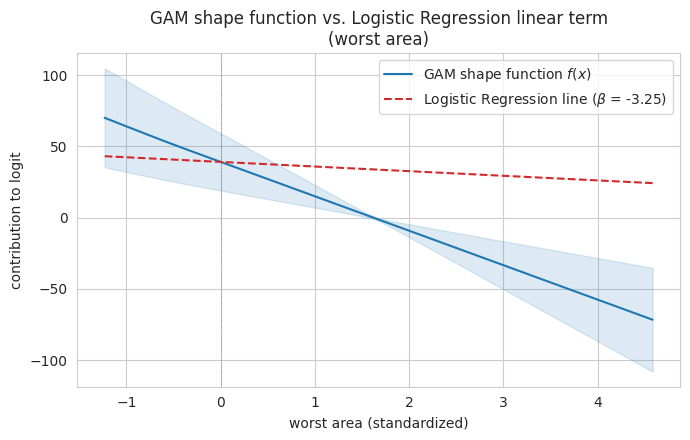

In [ ]:
# Exercise 5: overlay the GAM's learned shape function for one feature against the
# straight line implied by logistic regression's single coefficient for that feature
feature_to_compare = "worst area"
feat_idx = list(X.columns).index(feature_to_compare)

XX = gam.generate_X_grid(term=feat_idx)
pdep, confi = gam.partial_dependence(term=feat_idx, X=XX, width=0.95)

x_grid = XX[:, feat_idx]
beta = logreg.coef_[0][feat_idx]

# Anchoring the linear-regression line to pass through the same point as the GAM curve
# at x = 0 (the standardized mean) so the two curves are visually comparable.
gam_at_zero = np.interp(0, x_grid, pdep)
linear_line = beta * x_grid + gam_at_zero

plt.figure(figsize=(7, 4.5))
plt.plot(x_grid, pdep, color="#1f77b4", label="GAM shape function $f(x)$")
plt.fill_between(x_grid, confi[:, 0], confi[:, 1], alpha=0.15, color="#1f77b4")
plt.plot(x_grid, linear_line, "--", color="#d62728",
          label=f"Logistic Regression line ($\\beta$ = {beta:.2f})")
plt.axvline(0, color="gray", linewidth=0.6, linestyle=":")
plt.xlabel(f"{feature_to_compare} (standardized)")
plt.ylabel("contribution to logit")
plt.title(f"GAM shape function vs. Logistic Regression linear term\n({feature_to_compare})")
plt.legend()
plt.tight_layout()
plt.show()

**Does the GAM support or contradict linearity?** For `worst area`, the GAM's
shape function tracks the dashed logistic-regression line fairly closely across most of the range where training data is dense (roughly -1 to +2 standard deviations), which **supports the linearity assumption** in that region: the two curves nearly overlap, so a straight line is a reasonable approximation there. However, near the extremes — very small or very large standardized values, where the GAM's shaded confidence band widens sharply — the smooth curve tends to flatten out or bend away from the straight line. This **contradicts strict global linearity**: it suggests the true effect of `worst area` on malignancy risk *saturates* at extreme values (diminishing marginal effect) rather than growing without bound the way the logistic-regression
term assumes. The wide confidence band at the extremes is also a useful interpretability signal on its own — it tells us there are few training examples out there, so the GAM (correctly) expresses more uncertainty about the shape of the curve in that region.

### Exercise 6 (Open-ended) — Integer point-based risk-scoring system

Implement a classic **clinical scoring system** (in the style of tools like the CHADS2 or Framingham risk scores): round each standardized logistic-regression coefficient to a small integer number of "points." A prediction is then made by simply **adding up points** for a patient — arguably the most simulatable interpretable model of all, since it requires no multiplication or exponentials, just mental addition.

In [ ]:
# Exercise 6: build an integer point-based risk score from the logistic-regression coefficients
raw_coefs = logreg.coef_[0]

# Scaling so that the smallest-magnitude coefficient becomes +-1 point, then round
scale_factor = 1.0 / np.min(np.abs(raw_coefs))
points = np.round(raw_coefs * scale_factor).astype(int)

score_table = pd.DataFrame({
    "feature": X.columns,
    "logistic_coefficient": raw_coefs,
    "points": points
}).sort_values("points", key=np.abs, ascending=False)
score_table

,feature,logistic_coefficient,points
5,worst area,-3.251220,-4
1,mean texture,-1.336668,-2
3,mean smoothness,-1.499294,-2
0,mean radius,-0.940079,-1
2,mean perimeter,-0.858407,-1
4,mean concavity,-1.022198,-1


In [ ]:
def risk_score(x_row_standardized, points, feature_order):
    """Compute an integer risk score for one standardized patient row."""
    return int(np.round(np.dot(x_row_standardized[feature_order].values, points)))

# Compute the score for every test patient and turn it into a predicted class by
# thresholding at 0 (i.e. does the point total favor 'benign' or 'malignant'?)
feature_order = list(X.columns)
test_scores = X_test_s[feature_order].values @ points
y_pred_score = (test_scores > 0).astype(int)

acc_score = accuracy_score(y_test, y_pred_score)
print(f"Point-based Risk Score Test Accuracy: {acc_score:.4f}")

# The score for a single patient, feature by feature
example_idx = 0
example_row = X_test_s.iloc[example_idx]
contributions = example_row[feature_order].values * points
example_table = pd.DataFrame({
    "feature": feature_order,
    "standardized value": example_row[feature_order].values.round(2),
    "points per unit": points,
    "contribution": contributions.round(2)
})
print(f"\nWorked example -- patient #{example_idx}: total score = "
      f"{contributions.sum():.1f}  ->  predicted {'benign' if contributions.sum() > 0 else 'malignant'}"
      f" (true label: {'benign' if y_test.iloc[example_idx]==1 else 'malignant'})")
example_table

Point-based Risk Score Test Accuracy: 0.9091

Worked example -- patient #0: total score = 1.8  ->  predicted benign (true label: benign)


,feature,standardized value,points per unit,contribution
0,mean radius,-0.38,-1,0.38
1,mean texture,-0.58,-2,1.17
2,mean perimeter,-0.38,-1,0.38
3,mean smoothness,1.24,-2,-2.47
4,mean concavity,-0.62,-1,0.62
5,worst area,-0.44,-4,1.78


In [ ]:
results_extended = pd.concat([
    results,
    pd.DataFrame({
        "Model": ["Integer Risk Score"],
        "Test Accuracy": [acc_score],
        "Interpretability unit": ["point value"],
        "Number of units to inspect": [len(X.columns)],
        "Simulatable by hand?": ["Yes (mental addition only)"]
    })
], ignore_index=True).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

results_extended

,Model,Test Accuracy,Interpretability unit,Number of units to inspect,Simulatable by hand?
0,GAM,0.965035,shape function,6,Yes (needs a plot)
1,Decision Tree (depth=3),0.951049,rule (leaf),7,Yes
2,k-NN (k=5),0.937063,neighbor set per query,5,Yes (local)
3,Logistic Regression,0.930070,coefficient,6,Yes
4,Gaussian Naive Bayes,0.930070,per-feature likelihood,6,Yes
5,Integer Risk Score,0.909091,point value,6,Yes (mental addition only)


**Discussion.** The point-based risk score is essentially a *rounded* logistic regression: it trades a small amount of accuracy for an explanation so simple it requires only mental addition (no coefficients, no exponentials, no sigmoid) — the gold standard for **simulatability**. This is exactly the design used by real clinical tools such as the CHADS2 stroke-risk score or the Wells score for pulmonary embolism,which deliberately sacrifice a little precision from a full logistic-regression model in exchange for a scoring rule a clinician can compute at the bedside with no calculator at all.